In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib

sys.path.append('..')
import plot_settings
plot_settings.apply()


import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)

import SPM_eqs
importlib.reload(SPM_eqs)

from IPython.display import display, Math

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#sol, model,_,params = exp_pybamm_ver3.generate_data(model='SPM', RNG = False)
sol, model,params = sim_PyBaMM.simulate(0.5)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
V_true = sol.observe(model.variables['Terminal voltage [V]'])(t)
I = sol.observe(model.variables['Current [A]'])(t)
ocp_p = sol.observe(model.variables['X-averaged positive electrode open-circuit potential [V]'])(t)
ocp_n = sol.observe(model.variables['X-averaged negative electrode open-circuit potential [V]'])(t)
cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1,:]
cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1,:]
jn0_true = sol.observe(model.variables['X-averaged negative electrode exchange current density [A.m-2]'])(t)
jp0_true = sol.observe(model.variables['X-averaged positive electrode exchange current density [A.m-2]'])(t)
OCV_true = sol.observe(model.variables['Surface open-circuit voltage [V]'])(t)

In [3]:
cn_norm = cn / params['Maximum concentration in negative electrode [mol.m-3]']
cp_norm = cp / params['Maximum concentration in positive electrode [mol.m-3]']

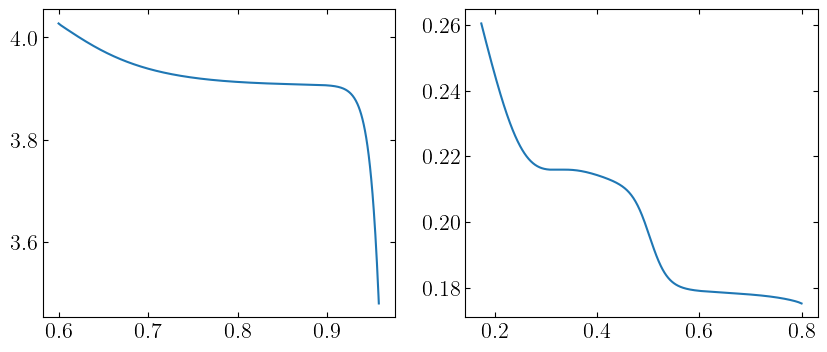

In [4]:
f, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(cp_norm, ocp_p, label='Positive Electrode')
ax[1].plot(cn_norm, ocp_n, label='Negative Electrode')

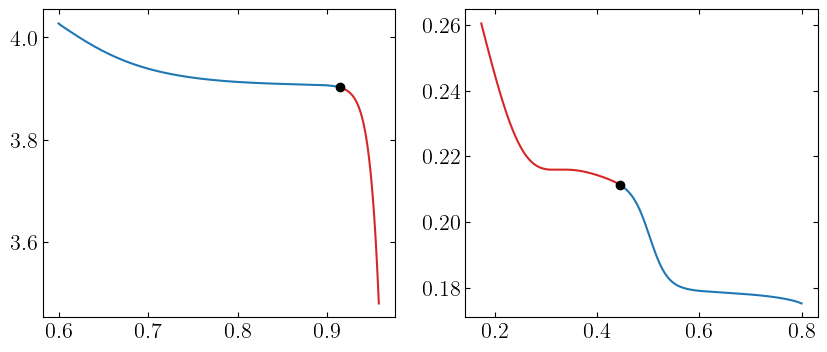

In [38]:
f, ax = plt.subplots(1,2,figsize=(10,4))
ip = 125
ax[0].plot(cp_norm[:-ip], ocp_p[:-ip], color = 'tab:blue',label='Positive Electrode')
ax[0].plot(cp_norm[-ip:], ocp_p[-ip:],color = 'tab:red', label='Positive Electrode')
V_p_int = ocp_p[-ip]
c_p_int = cp_norm[-ip]
ax[0].plot(c_p_int, V_p_int, 'ko', label='Positive Electrode')

i_n = 450
ax[1].plot(cn_norm[:-i_n], ocp_n[:-i_n],color = 'tab:blue', label='Negative Electrode')
ax[1].plot(cn_norm[-i_n:], ocp_n[-i_n:],color = 'tab:red', label='Negative Electrode')
V_n_int = ocp_n[-i_n]
c_n_int = cn_norm[-i_n]
ax[1].plot(c_n_int, V_n_int,'ko', label='Positive Electrode')


cn1_norm = cn_norm[:-i_n]
ocp_n1 = ocp_n[:-i_n]
cn2_norm = cn_norm[-i_n:]
ocp_n2 = ocp_n[-i_n:]   

cp1_norm = cp_norm[:-ip]
ocp_p1 = ocp_p[:-ip]
cp2_norm = cp_norm[-ip:]
ocp_p2 = ocp_p[-ip:]


In [26]:
from pysr import PySRRegressor, TemplateExpressionSpec
# import mean
from pysr import jl
jl.seval("using Statistics")

In [7]:

cn_norm = cn_norm.reshape(-1,1)
cp_norm = cp_norm.reshape(-1,1)
ocp_n = ocp_n.reshape(-1,1)
ocp_p = ocp_p.reshape(-1,1)

print(cn_norm.shape, ocp_n.shape)
print(cp_norm.shape, ocp_p.shape)

(1000, 1) (1000, 1)
(1000, 1) (1000, 1)


### Jonatan's guide to `PySR`

[API reference](https://ai.damtp.cam.ac.uk/pysr/v1.5.9/api.htm)

Based on evolutionary optimization, where a population of functions are evolved through mutations (randomly switch the binary operations) and crossovers (combining different functions with the binary operations). 

`model_selection` could be `'best'`, `'accuracy`, or `'score'`

`unary_operators`  `'sin'`, `'exp'`, a function that takes in a scalar

**Complexity** could be tuned. Default values are 1 for an operator, 1 for a constant and 1 for a binary operator. $0.5+2\sin(x)$, hence, has a complexity of 3.

**Other cool features and constraints**

- `dimensional_constraint_penalty`: penalizes expressions that don't have correct dimensions
- `dimensionless_constants_only`: penalizes constants that are not dimensionless
- `constraints`: For instance `'pow': (-1, 1)'` specifies that a power law is limited to a 1 complexity. 












In [ ]:
template_p = TemplateExpressionSpec(
    expressions = ['f'],
    variable_names=['x1'],
    combine=f'{V_p_int} + (x1 - {c_p_int}) * f(x1)'
)

template_n = TemplateExpressionSpec(
    expressions = ['f'],
    variable_names=['x1'],
    combine=f'{V_n_int} + (x1 - {c_n_int}) * f(x1)'
)

In [ ]:
model_n1 = PySRRegressor(
    model_selection="best",
    niterations=250,
    binary_operators=[
        "+", "*", '-','/'
    ],
    unary_operators=['tanh', 'sqrt','square', 'cube'],
    loss="loss(x, y) = (x - y)^2",
    populations=10,
    verbosity=0,
    expression_spec=template_n
)


model_p1 = PySRRegressor(
    model_selection="best",
    niterations=250,
    binary_operators=[
        "+", "*", '-','/'
    ],
    unary_operators=['sqrt','square', 'cube','tanh',],
    loss="loss(x, y) = (x - y)^2",
    populations=10,
    verbosity=0,
    expression_spec=template_p
)

   

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(


In [9]:
model_n.fit(cn_norm, ocp_n)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


,model_selection,'best'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['tanh', 'sqrt', ...]"
,expression_spec,None
,niterations,250
,populations,10
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


In [10]:
model_p.fit(cp_norm, ocp_p)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


,model_selection,'best'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['sqrt', 'square', ...]"
,expression_spec,None
,niterations,250
,populations,10
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


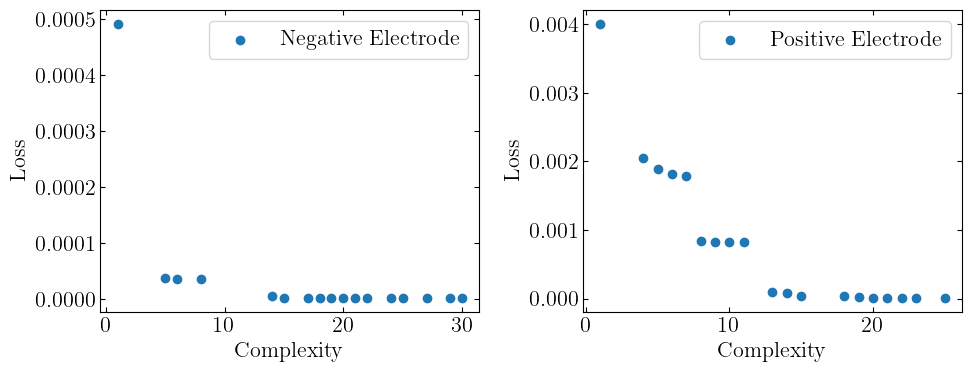

In [11]:
df_n = model_n.equations_
df_p = model_p.equations_

f, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].scatter(df_n['complexity'], df_n['loss'], label='Negative Electrode')
ax[1].scatter(df_p['complexity'], df_p['loss'], label='Positive Electrode')
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel('Complexity')
ax[0].set_ylabel('Loss')
ax[1].set_xlabel('Complexity')
ax[1].set_ylabel('Loss')
plt.tight_layout()

In [24]:
model_index = 3
display(Math('\\Large \\mathrm{Negative:}\\quad' + model_n.latex(model_index)))
display(Math('\\Large \\mathrm{Positive:}\\quad' + model_p.latex(model_index)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
#sol, model,_,params = exp_pybamm_ver3.generate_data(model='SPM', RNG = False)
sol, model,params = sim_PyBaMM.simulate_GRF(0.5, T=1000, T_horizon=3600)
t = np.linspace(0,sol['Time [s]'].entries[-1],1000)
V_true = sol.observe(model.variables['Terminal voltage [V]'])(t)
I = sol.observe(model.variables['Current [A]'])(t)
ocp_p = sol.observe(model.variables['X-averaged positive electrode open-circuit potential [V]'])(t)
ocp_n = sol.observe(model.variables['X-averaged negative electrode open-circuit potential [V]'])(t)
cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)[-1,:]
cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)[-1,:]
ce = sol.observe(model.variables['X-averaged electrolyte concentration [mol.m-3]'])(t)
OCV_true = sol.observe(model.variables['Surface open-circuit voltage [V]'])(t)


In [14]:
cn_norm = cn / params['Maximum concentration in negative electrode [mol.m-3]']
cp_norm = cp / params['Maximum concentration in positive electrode [mol.m-3]']
cn_norm = cn_norm.reshape(-1,1)
cp_norm = cp_norm.reshape(-1,1)
ocp_n = ocp_n.reshape(-1,1)
ocp_p = ocp_p.reshape(-1,1)

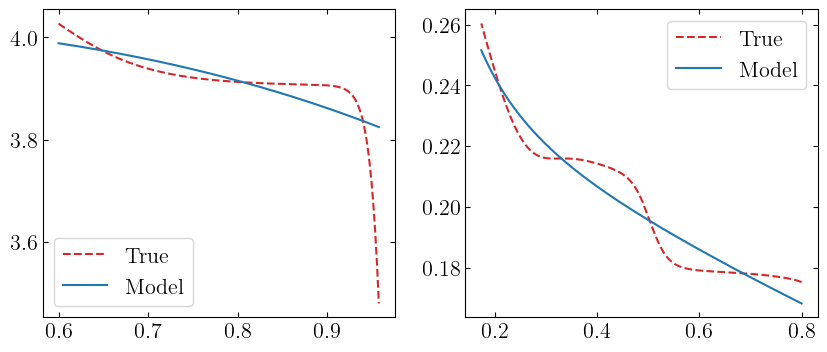

In [25]:
#cn_test = np.linspace(0,1,100).reshape(-1,1)
#cp_test = np.linspace(0,1,100).reshape(-1,1)

ocpn_pred = model_n.predict(cn_norm,model_index)
ocpp_pred = model_p.predict(cp_norm,model_index)

f, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(cp_norm, ocp_p, label='True',color = 'tab:red',ls = '--')
ax[0].plot(cp_norm, ocpp_pred, label='Model',color = 'tab:blue')
ax[1].plot(cn_norm, ocp_n, label='True',color = 'tab:red',ls = '--')
ax[1].plot(cn_norm, ocpn_pred, label='Model',color = 'tab:blue')
ax[0].legend()
ax[1].legend()  

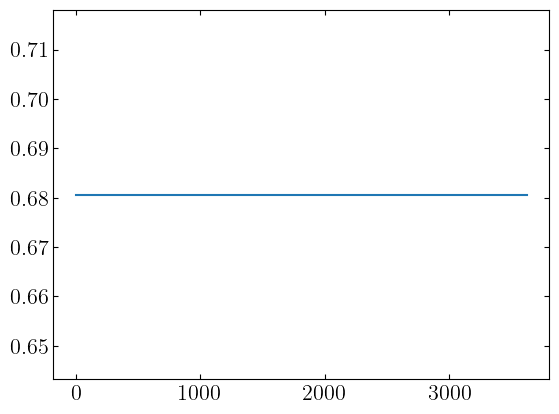

In [16]:
plt.plot(t,I, label='Model OCV',color = 'tab:blue')

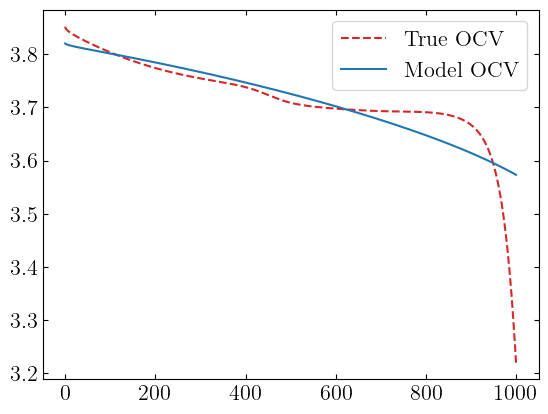

In [17]:
plt.plot(ocp_p - ocp_n, label='True OCV',color = 'tab:red',ls = '--')
plt.plot(ocpp_pred-ocpn_pred, label='Model OCV',color = 'tab:blue')
plt.legend()

In [18]:
Ln = params['Negative electrode thickness [m]']
Lp = params['Positive electrode thickness [m]']
A = params['Electrode height [m]'] * params['Electrode width [m]']
print(Ln, Lp, A)

0.0001 0.0001 0.028359000000000002


In [19]:
def r_laplace(u,r):
    return 2/r * np.gradient(u) + np.gradient(np.gradient(u))

def time_derivative(u,t):
    return np.gradient(u) / (t[1]-t[0])



/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_35322/3011438731.py:2: RuntimeWarning: divide by zero encountered in divide
  return 2/r * np.gradient(u) + np.gradient(np.gradient(u))


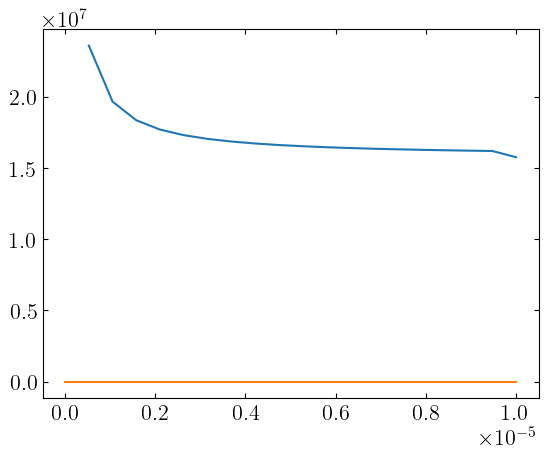

In [20]:
Dp = sol.observe(model.variables['X-averaged positive particle effective diffusivity [m2.s-1]'])(t)[0,:-1]
Dn = sol.observe(model.variables['X-averaged negative particle effective diffusivity [m2.s-1]'])(t)[0,:-1]
Cn = sol.observe(model.variables['X-averaged negative particle concentration [mol.m-3]'])(t)
Cp = sol.observe(model.variables['X-averaged positive particle concentration [mol.m-3]'])(t)

r = np.linspace(0,1e-5,len(Cp[:,0]))
ti = 100
dt = t[1] - t[0]
plt.plot(r, r_laplace(Cp[:,ti],r))
plt.plot(r,time_derivative(Cp[:,ti],t))
#plt.plot(r,(Cp[:,ti] - Cp[:,ti-1]) / dt)

(0.0, 2000.0)

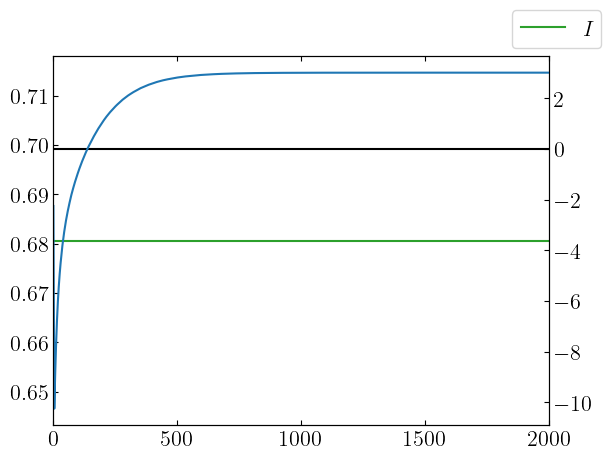

In [21]:
dcp = np.diff(cp, axis=0)
dcn = np.diff(cn, axis=0)
f, ax = plt.subplots()
axt = ax.twinx()
axt.axhline(0,0,t[-1],color = 'black')
#ax.plot(t[:-1],np.diff(I), label='$\\Delta I $',color = 'tab:red')
ax.plot(t,I, label='$I $',color = 'tab:green')
#axt.plot(t[:-1],dcp +dcn, label='$\\Delta c_p +\\Delta c_n$')
axt.plot(t[:-1], dcp + dcn)
#axt.plot(t[:-1], dcn)

f.legend()
ax.set_xlim(0,2000)

-0.8333333333340223


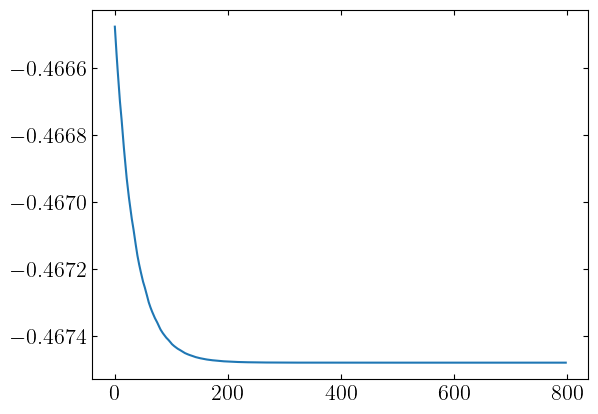

In [22]:
Dp = sol.observe(model.variables['X-averaged positive particle effective diffusivity [m2.s-1]'])(t)[0,:-1]
Dn = sol.observe(model.variables['X-averaged negative particle effective diffusivity [m2.s-1]'])(t)[0,:-1]
plt.plot(dcp[200:] / dcn[200:] * Dn[200:] / Dp[200:])
print(dcn[-1] / dcp[-1])

$dn_i = n_{i+1} - n_i$
$dp_i = p_{i+1} - p_i$

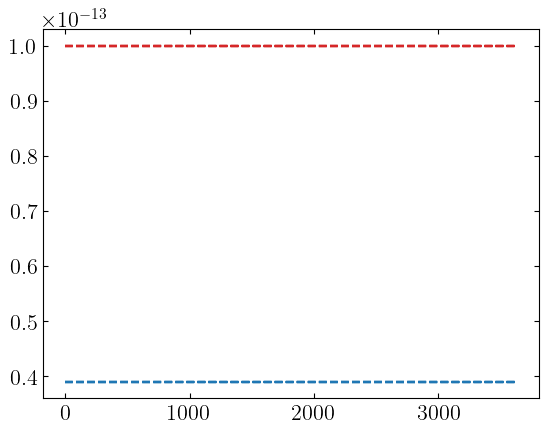

In [23]:
for i in range(10):
    plt.plot(t,sol.observe(model.variables['X-averaged positive particle effective diffusivity [m2.s-1]'])(t)[i,:], label='True OCV',color = 'tab:red',ls = '--')
    plt.plot(t,sol.observe(model.variables['X-averaged negative particle effective diffusivity [m2.s-1]'])(t)[i,:], label='True OCV',color = 'tab:blue',ls = '--')